<a href="https://www.kaggle.com/code/aamir28/screen-time-sleep-and-depressive-symptoms?scriptVersionId=341592925" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>


<div style="background:#F3F5F8; padding:44px 42px; border-radius:8px; border:1px solid #D3DAE3; font-family:Georgia,'Times New Roman',serif;">

  <div style="display:flex; justify-content:space-between; align-items:flex-start; margin-bottom:12px;">
    <span style="font-family:Arial,sans-serif; font-size:11px; font-weight:700; color:#4A5C73; letter-spacing:1.5px; text-transform:uppercase;">Adolescent Wellbeing Research</span>
    <span style="font-family:Arial,sans-serif; font-size:11px; color:#7A8AA0;">n = 4,810 ADOLESCENTS</span>
  </div>

  <h1 style="margin:0 0 8px 0; font-size:31px; color:#22303F; font-weight:700;">
    Screen Time, Sleep, and Depressive Symptoms
  </h1>
  <p style="margin:0 0 26px 0; font-size:15px; color:#4A5C73; max-width:660px;">
    A cohort analysis linking self-reported screen use, sleep quality, and Beck Depression Inventory (BDI-II) scores in adolescents
  </p>

  <div style="display:grid; grid-template-columns:repeat(4,1fr); gap:14px;">
    <div style="background:#FFFFFF; border:1px solid #D3DAE3; border-radius:8px; padding:14px; text-align:center;">
      <div style="color:#4A5C73; font-size:20px; font-weight:800;">4,810</div>
      <div style="font-size:10.5px; color:#7A8AA0; margin-top:2px;">PARTICIPANTS</div>
    </div>
    <div style="background:#FFFFFF; border:1px solid #D3DAE3; border-radius:8px; padding:14px; text-align:center;">
      <div style="color:#4A5C73; font-size:20px; font-weight:800;">2</div>
      <div style="font-size:10.5px; color:#7A8AA0; margin-top:2px;">SOURCE FILES</div>
    </div>
    <div style="background:#FFFFFF; border:1px solid #D3DAE3; border-radius:8px; padding:14px; text-align:center;">
      <div style="color:#4A5C73; font-size:20px; font-weight:800;">21</div>
      <div style="font-size:10.5px; color:#7A8AA0; margin-top:2px;">BDI-II ITEMS</div>
    </div>
    <div style="background:#FFFFFF; border:1px solid #D3DAE3; border-radius:8px; padding:14px; text-align:center;">
      <div style="color:#4A5C73; font-size:20px; font-weight:800;">16.4%</div>
      <div style="font-size:10.5px; color:#7A8AA0; margin-top:2px;">ABOVE SCREENING CUTOFF</div>
    </div>
  </div>

  <div style="margin-top:22px; padding:14px 18px; background:#EAF0F6; border-radius:8px; border-left:3px solid #4A5C73;">
    <p style="margin:0; font-size:12.5px; color:#2E3D4E; line-height:1.7;">
      <b>About this notebook:</b> this is an aggregate, cohort-level analysis of a research dataset — it studies
      group patterns, not individuals, and the BDI-II is a screening tool, not a diagnosis. Nothing here is
      intended to assess any individual's mental health. If anything in this topic feels personally relevant,
      talking to a counselor, doctor, or trusted adult is always a good next step.
    </p>
  </div>

  <p style="margin:16px 0 0 0; font-size:12.5px; color:#7A8AA0;">
    Author: <b style="color:#22303F;">Muhammad Aamir</b> &nbsp;|&nbsp; Files: <code>bdi_and_screen_items.csv</code> + <code>screen_time_mental_health.csv</code>
  </p>

</div>



<div style="background:#FFFFFF; border-left:4px solid #4A5C73; border-radius:8px; padding:20px 26px; font-family:Georgia,serif; color:#22303F;">
<h3 style="margin-top:0; font-weight:700; color:#4A5C73; letter-spacing:0.5px; font-size:13px; text-transform:uppercase;">Contents</h3>
<ol style="line-height:2; font-size:14.5px; color:#333;">
<li><a href="#setup" style="color:#4A5C73; text-decoration:none;">Setup &amp; Report Styling</a></li>
<li><a href="#firstlook" style="color:#4A5C73; text-decoration:none;">First Look &amp; Merging the Files</a></li>
<li><a href="#quality" style="color:#4A5C73; text-decoration:none;">Data Quality &amp; Validation</a></li>
<li><a href="#landscape" style="color:#4A5C73; text-decoration:none;">Screen Time &amp; Sleep Landscape</a></li>
<li><a href="#bditotal" style="color:#4A5C73; text-decoration:none;">BDI-II Scores &amp; Screening Classification</a></li>
<li><a href="#sex" style="color:#4A5C73; text-decoration:none;">Differences by Sex</a></li>
<li><a href="#sleep" style="color:#4A5C73; text-decoration:none;">Sleep Quality &amp; Depressive Symptoms</a></li>
<li><a href="#screen" style="color:#4A5C73; text-decoration:none;">Screen Time &amp; Depressive Symptoms</a></li>
<li><a href="#jetlag" style="color:#4A5C73; text-decoration:none;">Social Jetlag &amp; Other Factors</a></li>
<li><a href="#items" style="color:#4A5C73; text-decoration:none;">Item-Level Variability (Aggregate Only)</a></li>
<li><a href="#corr" style="color:#4A5C73; text-decoration:none;">Correlation Check</a></li>
<li><a href="#dashboard" style="color:#4A5C73; text-decoration:none;">Cohort Dashboard</a></li>
<li><a href="#model" style="color:#4A5C73; text-decoration:none;">Predicting the Screening Classification</a></li>
<li><a href="#conclusion" style="color:#4A5C73; text-decoration:none;">Closing Notes</a></li>
</ol>
</div>


<h2 id="setup" style="font-family:Georgia,serif; color:#22303F; border-bottom:2px solid #4A5C73; padding-bottom:8px;">⚙️ 1. Setup &amp; Report Styling</h2>

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import FancyBboxPatch
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ---- "Academic Research Report" calm slate palette ----
BG        = '#F3F5F8'
PANEL     = '#FFFFFF'
INK       = '#22303F'
INK_SOFT  = '#7A8AA0'
SLATE     = '#4A5C73'
TEAL      = '#4C8C8C'
AMBER     = '#C99A3E'
CORAL     = '#C46B5E'
LAVENDER  = '#8C7FB0'
GRID      = '#E3E8EE'

SEX_COLORS = {'Boy': SLATE, 'Girl': CORAL}
DEP_COLORS = {0: TEAL, 1: CORAL}
PALETTE_CAT = [SLATE, TEAL, AMBER, CORAL, LAVENDER]

plt.rcParams.update({
    'figure.facecolor': BG,
    'axes.facecolor': PANEL,
    'savefig.facecolor': BG,
    'axes.edgecolor': GRID,
    'axes.labelcolor': INK,
    'text.color': INK,
    'xtick.color': INK_SOFT,
    'ytick.color': INK_SOFT,
    'axes.grid': True,
    'grid.color': GRID,
    'grid.linewidth': 0.8,
    'grid.alpha': 0.9,
    'font.family': 'serif',
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

sns.set_palette(sns.color_palette(PALETTE_CAT))

def style_ax(ax, title=None, xlabel=None, ylabel=None):
    if title: ax.set_title(title, color=INK, pad=12, fontsize=13)
    if xlabel: ax.set_xlabel(xlabel, color=INK_SOFT)
    if ylabel: ax.set_ylabel(ylabel, color=INK_SOFT)
    ax.spines['left'].set_color(GRID)
    ax.spines['bottom'].set_color(GRID)
    return ax

print("Report styling loaded.")


Report styling loaded.


<h2 id="firstlook" style="font-family:Georgia,serif; color:#22303F; border-bottom:2px solid #4A5C73; padding-bottom:8px;">🗂️ 2. First Look &amp; Merging the Files</h2>

In [2]:

bdi = pd.read_csv('/kaggle/input/datasets/kylefengkfeng209/screen-time-vs-mental-health-ml-ready/bdi_and_screen_items.csv')
screen = pd.read_csv('/kaggle/input/datasets/kylefengkfeng209/screen-time-vs-mental-health-ml-ready/screen_time_mental_health.csv')

print(f"bdi_and_screen_items.csv: {bdi.shape[0]:,} rows x {bdi.shape[1]} columns")
print(f"screen_time_mental_health.csv: {screen.shape[0]:,} rows x {screen.shape[1]} columns")
print(f"\nSame subject_id set in both files: {set(bdi.subject_id) == set(screen.subject_id)}")

df = bdi.merge(screen, on='subject_id', how='inner')
print(f"\nMerged dataset: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head(3)


bdi_and_screen_items.csv: 4,810 rows x 29 columns
screen_time_mental_health.csv: 4,810 rows x 10 columns

Same subject_id set in both files: True

Merged dataset: 4,810 rows x 38 columns


,subject_id,screen_normal_day_1to6,screen_weekday_1to6,screen_weekend_1to6,sqi_fall_asleep_1to6,sqi_repeated_awake_1to6,sqi_disturbed_1to6,sqi_early_awake_1to6,bdi_item_01,bdi_item_02,...,bdi_item_21,sex,screen_time_index,est_leisure_screen_hours,sleep_quality_index,avg_sleep_hours,midsleep_weekend_hours,social_jetlag_hours,bdi_total,depressed
0,1,2,3,5,1,3,2,3,0,1,...,0,Boy,3.333,4.64,2.25,8.36,4.58,1.92,6,0
1,2,3,3,4,4,2,3,1,1,0,...,0,Girl,3.333,4.07,2.50,7.31,5.42,2.25,7,0
2,3,3,3,4,3,1,3,1,1,1,...,1,Boy,3.333,4.07,2.00,8.75,5.50,2.62,27,1


<h2 id="quality" style="font-family:Georgia,serif; color:#22303F; border-bottom:2px solid #4A5C73; padding-bottom:8px;">✅ 3. Data Quality &amp; Validation</h2>

In [3]:

print("Duplicate rows:", df.duplicated().sum())
print("Missing values:", df.isnull().sum().sum())

item_cols = [c for c in df.columns if c.startswith('bdi_item_')]
print(f"\n{len(item_cols)} BDI-II item columns found, each scored 0-3 (standard BDI-II item range):")
print(f"  min={df[item_cols].min().min()}, max={df[item_cols].max().max()}")

calc_total = df[item_cols].sum(axis=1)
total_match = (calc_total == df['bdi_total']).all()
print(f"\nSum of 21 items matches the reported bdi_total for every row: {total_match}")

cutoff_check = df.groupby('depressed')['bdi_total'].agg(['min','max'])
print(f"\n'depressed' flag boundaries:\n{cutoff_check}")
print("This matches the standard published BDI-II clinical cutoff (score >= 14 = at least mild depressive symptoms) —")
print("a good sign this dataset was scored using accepted methodology rather than an arbitrary threshold.")


Duplicate rows: 0
Missing values: 0

21 BDI-II item columns found, each scored 0-3 (standard BDI-II item range):
  min=0, max=3

Sum of 21 items matches the reported bdi_total for every row: True

'depressed' flag boundaries:
           min  max
depressed          
0            0   13
1           14   51
This matches the standard published BDI-II clinical cutoff (score >= 14 = at least mild depressive symptoms) —
a good sign this dataset was scored using accepted methodology rather than an arbitrary threshold.


<h2 id="landscape" style="font-family:Georgia,serif; color:#22303F; border-bottom:2px solid #4A5C73; padding-bottom:8px;">📱 4. Screen Time &amp; Sleep Landscape</h2>

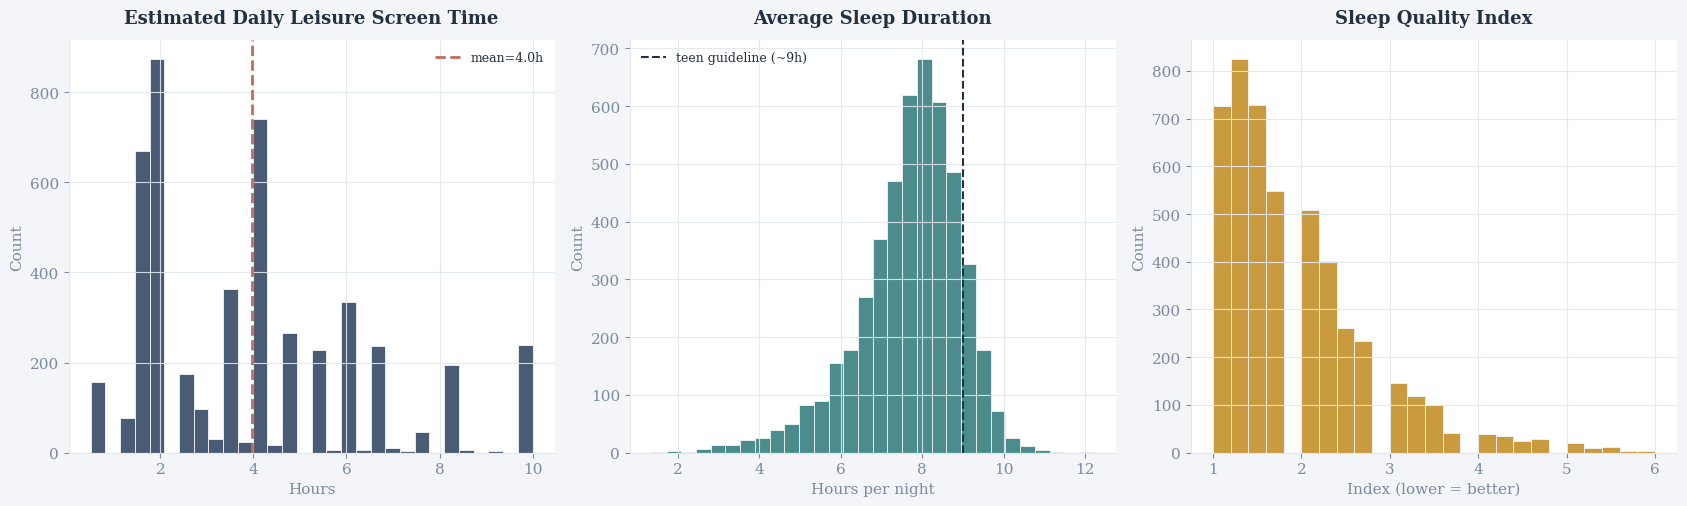

In [4]:

fig, axes = plt.subplots(1, 3, figsize=(17, 5.2))

ax = axes[0]
ax.hist(df['est_leisure_screen_hours'], bins=30, color=SLATE, edgecolor=BG, linewidth=0.6)
ax.axvline(df['est_leisure_screen_hours'].mean(), color=CORAL, linestyle='--', linewidth=2, label=f"mean={df['est_leisure_screen_hours'].mean():.1f}h")
style_ax(ax, 'Estimated Daily Leisure Screen Time', 'Hours', 'Count')
ax.legend(frameon=False, fontsize=9)

ax = axes[1]
ax.hist(df['avg_sleep_hours'], bins=30, color=TEAL, edgecolor=BG, linewidth=0.6)
ax.axvline(9, color=INK, linestyle='--', linewidth=1.5, label='teen guideline (~9h)')
style_ax(ax, 'Average Sleep Duration', 'Hours per night', 'Count')
ax.legend(frameon=False, fontsize=9)

ax = axes[2]
ax.hist(df['sleep_quality_index'], bins=25, color=AMBER, edgecolor=BG, linewidth=0.6)
style_ax(ax, 'Sleep Quality Index', 'Index (lower = better)', 'Count')

plt.tight_layout()
plt.show()


<h2 id="bditotal" style="font-family:Georgia,serif; color:#22303F; border-bottom:2px solid #4A5C73; padding-bottom:8px;">📋 5. BDI-II Scores &amp; Screening Classification</h2>

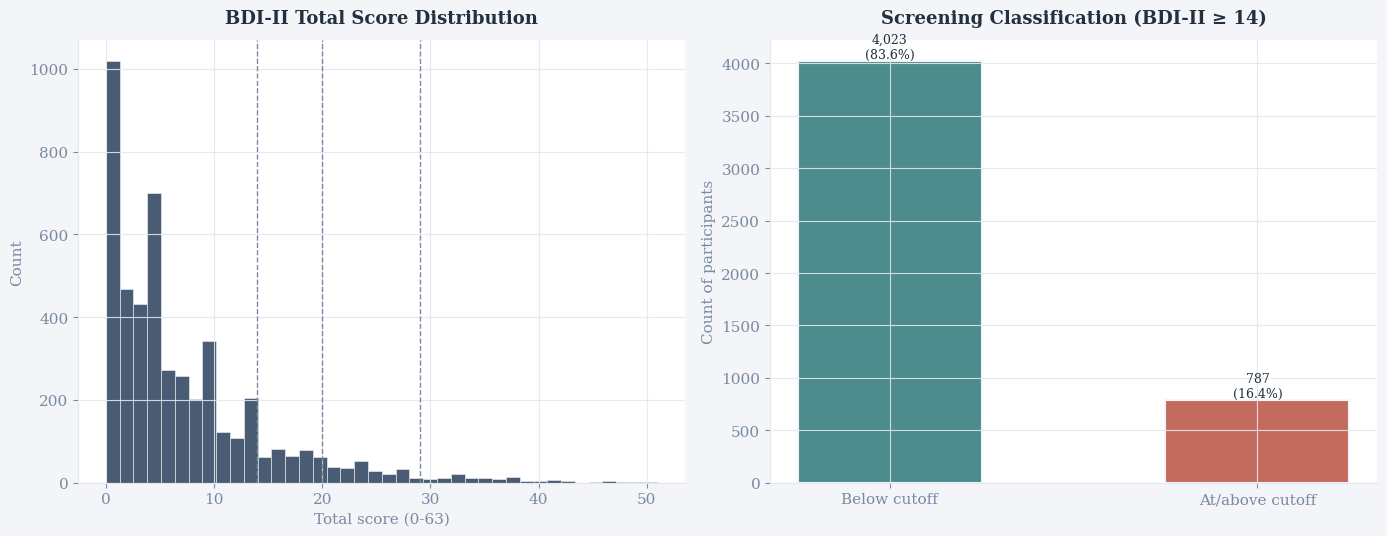

16.4% of this cohort scores at or above the standard BDI-II screening cutoff for
at least mild depressive symptoms — a screening result, not a clinical diagnosis, which would require a full assessment.


In [5]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

ax = axes[0]
ax.hist(df['bdi_total'], bins=40, color=SLATE, edgecolor=BG, linewidth=0.4)
for cutoff, label in [(14,'mild'), (20,'moderate'), (29,'severe')]:
    ax.axvline(cutoff, color=INK_SOFT, linestyle='--', linewidth=1)
style_ax(ax, 'BDI-II Total Score Distribution', 'Total score (0-63)', 'Count')

ax = axes[1]
dep_counts = df['depressed'].value_counts().sort_index()
bars = ax.bar(['Below cutoff','At/above cutoff'], dep_counts.values, color=[TEAL, CORAL], edgecolor=BG, linewidth=1.5, width=0.5)
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+30, f"{b.get_height():,}\n({b.get_height()/len(df)*100:.1f}%)", ha='center', fontsize=9, color=INK)
style_ax(ax, 'Screening Classification (BDI-II ≥ 14)', '', 'Count of participants')

plt.tight_layout()
plt.show()

print(f"{df['depressed'].mean()*100:.1f}% of this cohort scores at or above the standard BDI-II screening cutoff for")
print("at least mild depressive symptoms — a screening result, not a clinical diagnosis, which would require a full assessment.")


<h2 id="sex" style="font-family:Georgia,serif; color:#22303F; border-bottom:2px solid #4A5C73; padding-bottom:8px;">👥 6. Differences by Sex</h2>

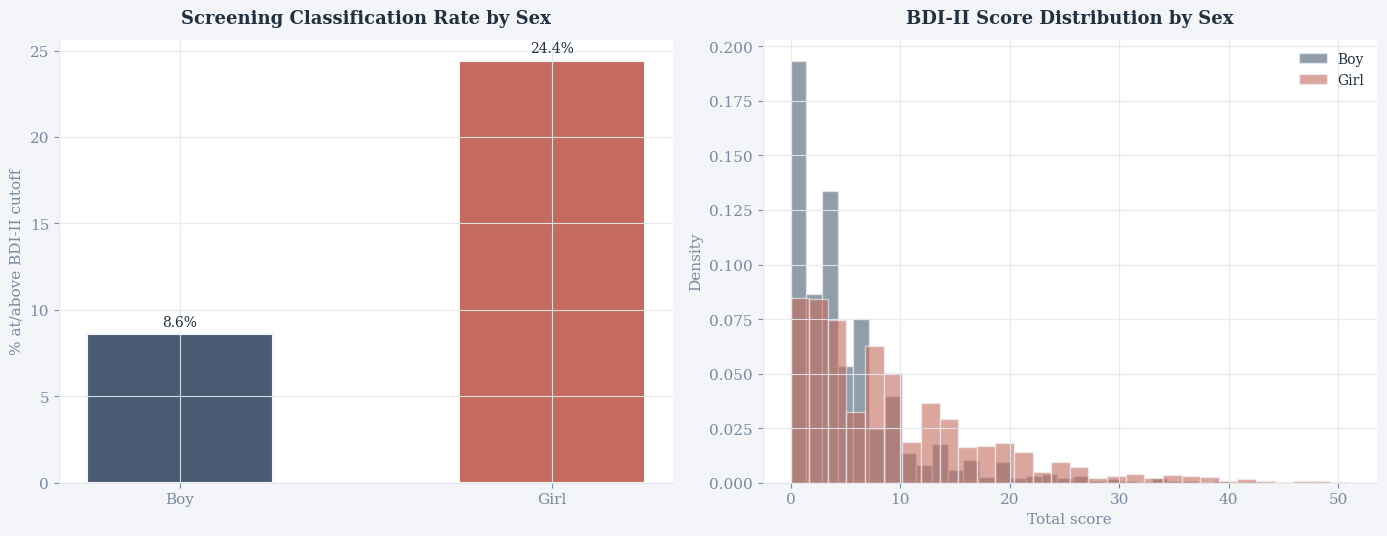

Girls in this cohort show a notably higher screening rate (24.4%) than boys (8.6%) —
a pattern consistent with a large body of published research showing a sex gap in adolescent depressive
symptoms that widens through the teenage years.


In [6]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

ax = axes[0]
sex_dep = df.groupby('sex')['depressed'].mean()*100
bars = ax.bar(sex_dep.index, sex_dep.values, color=[SEX_COLORS[s] for s in sex_dep.index], edgecolor=BG, linewidth=1.5, width=0.5)
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.5, f"{b.get_height():.1f}%", ha='center', fontsize=10, color=INK)
style_ax(ax, 'Screening Classification Rate by Sex', '', '% at/above BDI-II cutoff')

ax = axes[1]
for sex, c in SEX_COLORS.items():
    ax.hist(df[df.sex==sex]['bdi_total'], bins=30, alpha=0.6, color=c, label=sex, density=True, edgecolor=BG)
style_ax(ax, 'BDI-II Score Distribution by Sex', 'Total score', 'Density')
ax.legend(frameon=False, fontsize=10)

plt.tight_layout()
plt.show()

print(f"Girls in this cohort show a notably higher screening rate ({sex_dep['Girl']:.1f}%) than boys ({sex_dep['Boy']:.1f}%) —")
print("a pattern consistent with a large body of published research showing a sex gap in adolescent depressive")
print("symptoms that widens through the teenage years.")


<h2 id="sleep" style="font-family:Georgia,serif; color:#22303F; border-bottom:2px solid #4A5C73; padding-bottom:8px;">😴 7. Sleep Quality &amp; Depressive Symptoms</h2>

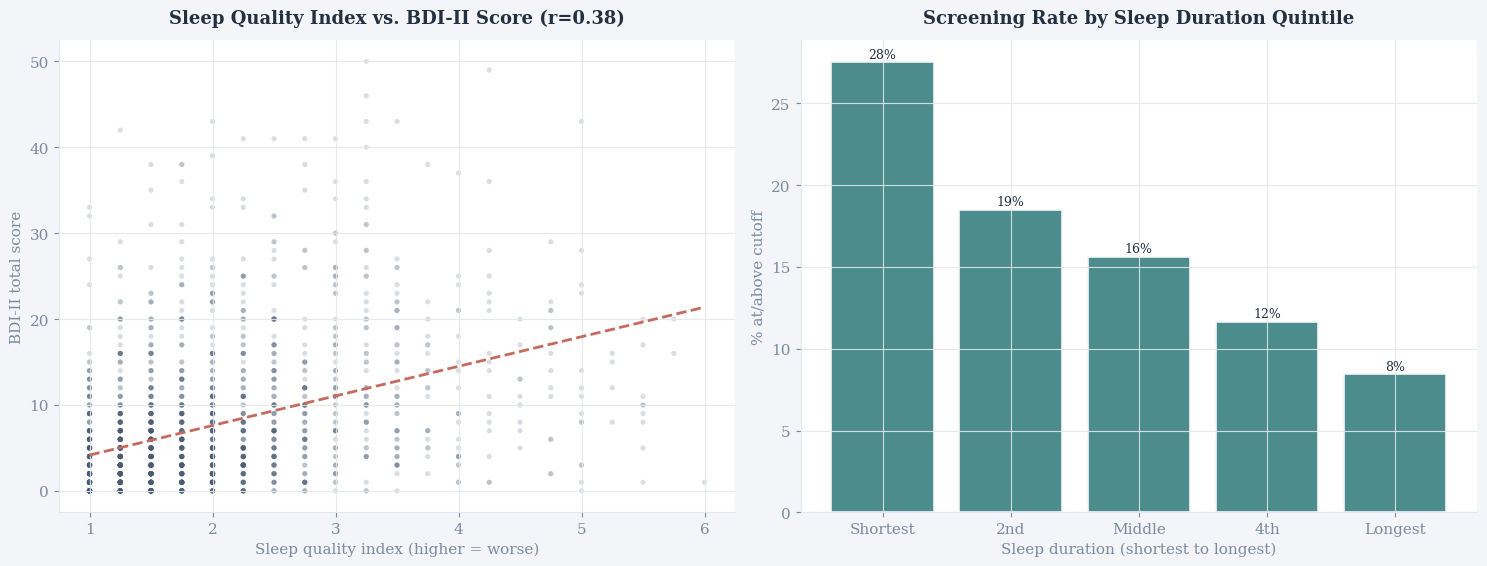

Sleep quality shows the strongest relationship with BDI-II score of any lifestyle factor in this dataset
(r=0.38) — poorer sleep quality associates with higher depressive symptom scores, and the shortest-sleep
quintile shows a clearly higher screening rate than the longest-sleep quintile.


In [7]:

fig, axes = plt.subplots(1, 2, figsize=(15, 5.8))

ax = axes[0]
sample = df.sample(2000, random_state=1)
ax.scatter(sample['sleep_quality_index'], sample['bdi_total'], alpha=0.2, s=14, color=SLATE, edgecolor='none')
z = np.polyfit(df['sleep_quality_index'], df['bdi_total'], 1)
xline = np.linspace(df['sleep_quality_index'].min(), df['sleep_quality_index'].max(), 50)
ax.plot(xline, np.poly1d(z)(xline), color=CORAL, linewidth=2, linestyle='--')
r = df['sleep_quality_index'].corr(df['bdi_total'])
style_ax(ax, f'Sleep Quality Index vs. BDI-II Score (r={r:.2f})', 'Sleep quality index (higher = worse)', 'BDI-II total score')

ax = axes[1]
sleep_bins = pd.qcut(df['avg_sleep_hours'], 5, labels=['Shortest','2nd','Middle','4th','Longest'])
sleep_dep = df.groupby(sleep_bins, observed=True)['depressed'].mean()*100
bars = ax.bar(sleep_dep.index.astype(str), sleep_dep.values, color=TEAL, edgecolor=BG, linewidth=1.2)
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.3, f"{b.get_height():.0f}%", ha='center', fontsize=9, color=INK)
style_ax(ax, 'Screening Rate by Sleep Duration Quintile', 'Sleep duration (shortest to longest)', '% at/above cutoff')

plt.tight_layout()
plt.show()

print(f"Sleep quality shows the strongest relationship with BDI-II score of any lifestyle factor in this dataset")
print(f"(r={r:.2f}) — poorer sleep quality associates with higher depressive symptom scores, and the shortest-sleep")
print("quintile shows a clearly higher screening rate than the longest-sleep quintile.")


<h2 id="screen" style="font-family:Georgia,serif; color:#22303F; border-bottom:2px solid #4A5C73; padding-bottom:8px;">📲 8. Screen Time &amp; Depressive Symptoms</h2>

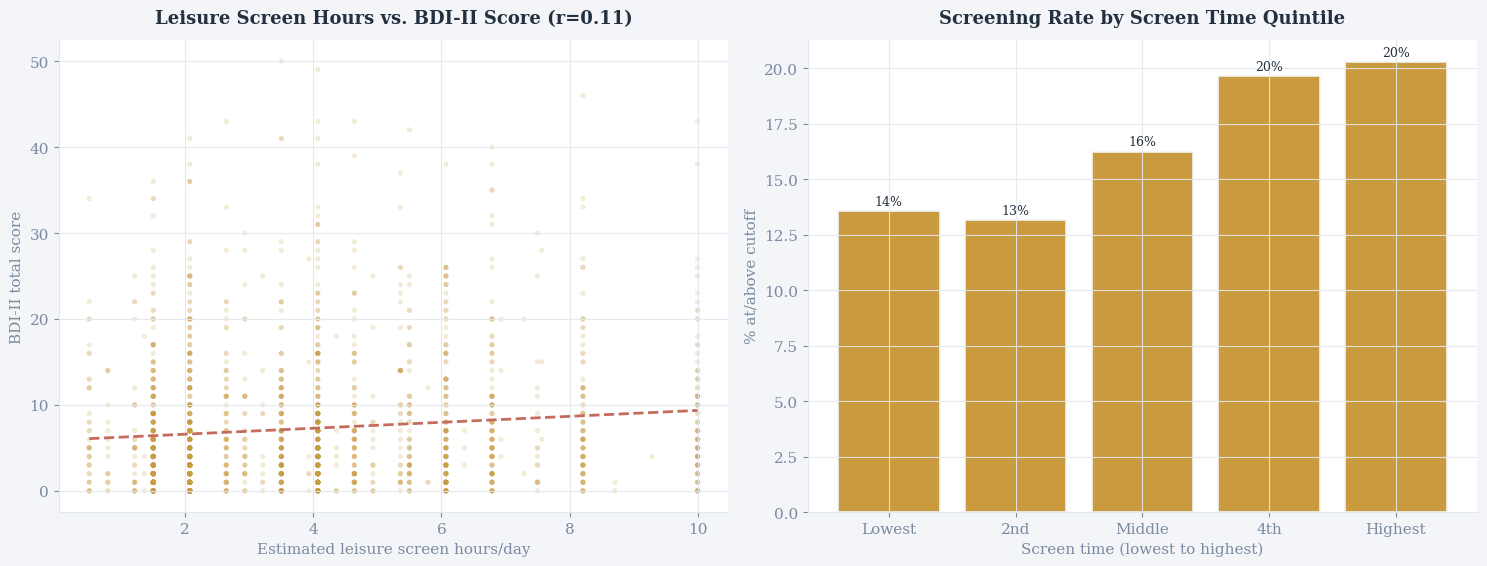

Screen time shows a real but noticeably weaker relationship with BDI-II score (r=0.11) than sleep quality
did (r=0.38) — in this cohort, how well someone sleeps tracks more closely with depressive symptoms than
how many hours they spend on screens, echoing a common finding in this research area: screen time's effect
is often smaller than headlines suggest, and may partly work *through* its effect on sleep.


In [8]:

fig, axes = plt.subplots(1, 2, figsize=(15, 5.8))

ax = axes[0]
ax.scatter(sample['est_leisure_screen_hours'], sample['bdi_total'], alpha=0.2, s=14, color=AMBER, edgecolor='none')
z2 = np.polyfit(df['est_leisure_screen_hours'], df['bdi_total'], 1)
xline2 = np.linspace(df['est_leisure_screen_hours'].min(), df['est_leisure_screen_hours'].max(), 50)
ax.plot(xline2, np.poly1d(z2)(xline2), color=CORAL, linewidth=2, linestyle='--')
r2 = df['est_leisure_screen_hours'].corr(df['bdi_total'])
style_ax(ax, f'Leisure Screen Hours vs. BDI-II Score (r={r2:.2f})', 'Estimated leisure screen hours/day', 'BDI-II total score')

ax = axes[1]
screen_bins = pd.qcut(df['est_leisure_screen_hours'], 5, labels=['Lowest','2nd','Middle','4th','Highest'])
screen_dep = df.groupby(screen_bins, observed=True)['depressed'].mean()*100
bars = ax.bar(screen_dep.index.astype(str), screen_dep.values, color=AMBER, edgecolor=BG, linewidth=1.2)
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.3, f"{b.get_height():.0f}%", ha='center', fontsize=9, color=INK)
style_ax(ax, 'Screening Rate by Screen Time Quintile', 'Screen time (lowest to highest)', '% at/above cutoff')

plt.tight_layout()
plt.show()

print(f"Screen time shows a real but noticeably weaker relationship with BDI-II score (r={r2:.2f}) than sleep quality")
print(f"did (r={r:.2f}) — in this cohort, how well someone sleeps tracks more closely with depressive symptoms than")
print("how many hours they spend on screens, echoing a common finding in this research area: screen time's effect")
print("is often smaller than headlines suggest, and may partly work *through* its effect on sleep.")


<h2 id="jetlag" style="font-family:Georgia,serif; color:#22303F; border-bottom:2px solid #4A5C73; padding-bottom:8px;">🌐 9. Social Jetlag &amp; Other Factors</h2>
<p style="color:#7A8AA0; font-family:Georgia,serif;"><i>Social jetlag</i> is the mismatch between a person's sleep timing on school days versus free days — a marker of circadian disruption.</p>

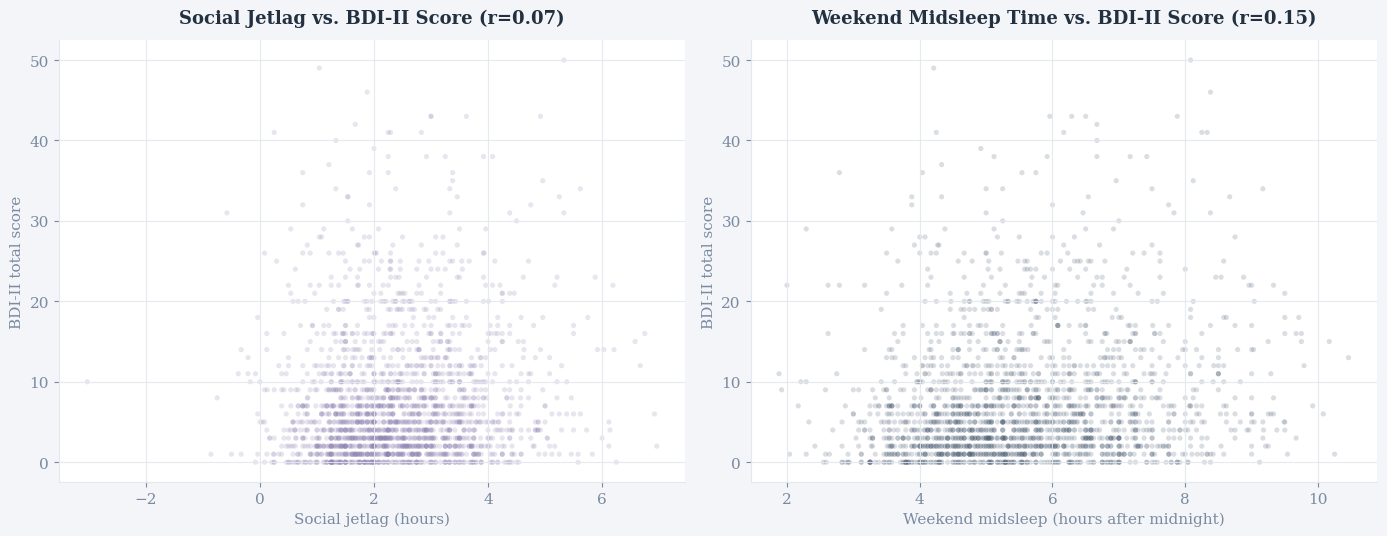

Both show weak positive relationships — later, more irregular sleep timing associates mildly with higher
depressive symptom scores, though neither is as strong a signal as overall sleep quality.


In [9]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

ax = axes[0]
ax.scatter(sample['social_jetlag_hours'], sample['bdi_total'], alpha=0.2, s=14, color=LAVENDER, edgecolor='none')
r3 = df['social_jetlag_hours'].corr(df['bdi_total'])
style_ax(ax, f'Social Jetlag vs. BDI-II Score (r={r3:.2f})', 'Social jetlag (hours)', 'BDI-II total score')

ax = axes[1]
r4 = df['midsleep_weekend_hours'].corr(df['bdi_total'])
ax.scatter(sample['midsleep_weekend_hours'], sample['bdi_total'], alpha=0.2, s=14, color=SLATE, edgecolor='none')
style_ax(ax, f'Weekend Midsleep Time vs. BDI-II Score (r={r4:.2f})', 'Weekend midsleep (hours after midnight)', 'BDI-II total score')

plt.tight_layout()
plt.show()

print("Both show weak positive relationships — later, more irregular sleep timing associates mildly with higher")
print("depressive symptom scores, though neither is as strong a signal as overall sleep quality.")


<h2 id="items" style="font-family:Georgia,serif; color:#22303F; border-bottom:2px solid #4A5C73; padding-bottom:8px;">📊 10. Item-Level Variability (Aggregate Only)</h2>
<p style="color:#7A8AA0; font-family:Georgia,serif;">The BDI-II total is built from 21 individual items. We look at aggregate endorsement levels only — items are numbered generically here rather than described individually, since the instrument's specific content is copyrighted and this notebook is about cohort-level patterns, not item interpretation.</p>

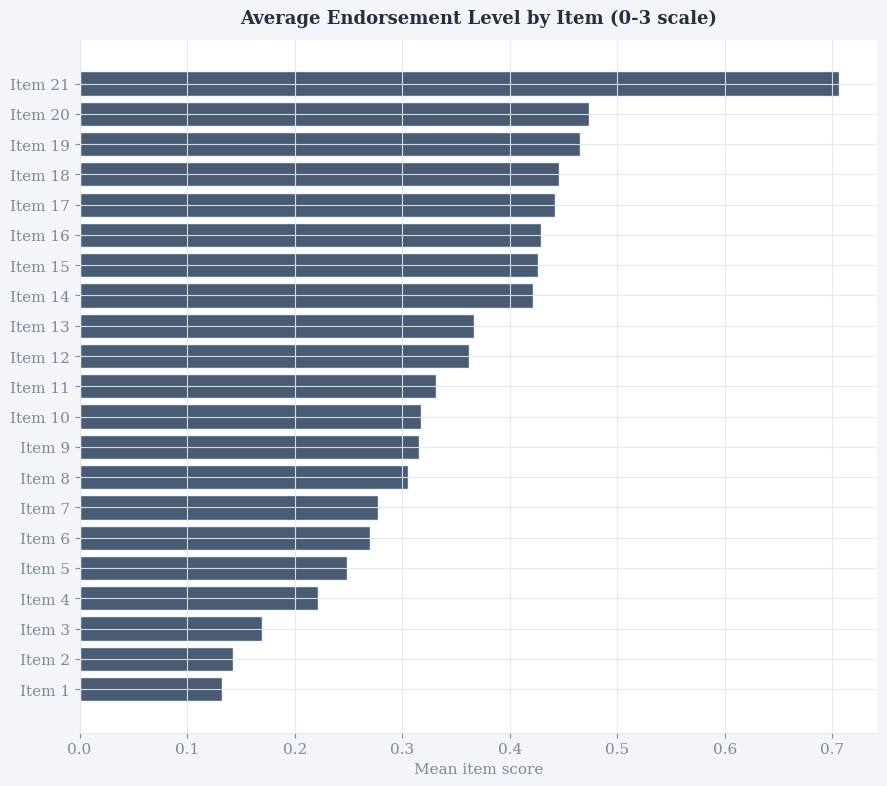

Average item scores range from 0.13 to 0.71 on the 0-3 scale —
items cluster around relatively low average endorsement overall, consistent with a cohort where most
participants (84%) fall below the clinical screening cutoff.


In [10]:

item_means = df[item_cols].mean().sort_values()
item_labels = [f"Item {i+1}" for i in range(len(item_means))]

fig, ax = plt.subplots(figsize=(9, 8))
ax.barh(item_labels, item_means.reindex(item_means.index).values, color=SLATE, edgecolor=BG, linewidth=1.0)
style_ax(ax, 'Average Endorsement Level by Item (0-3 scale)', 'Mean item score', '')
plt.tight_layout()
plt.show()

print(f"Average item scores range from {item_means.min():.2f} to {item_means.max():.2f} on the 0-3 scale —")
print("items cluster around relatively low average endorsement overall, consistent with a cohort where most")
print(f"participants ({(1-df['depressed'].mean())*100:.0f}%) fall below the clinical screening cutoff.")


<h2 id="corr" style="font-family:Georgia,serif; color:#22303F; border-bottom:2px solid #4A5C73; padding-bottom:8px;">🔗 11. Correlation Check</h2>

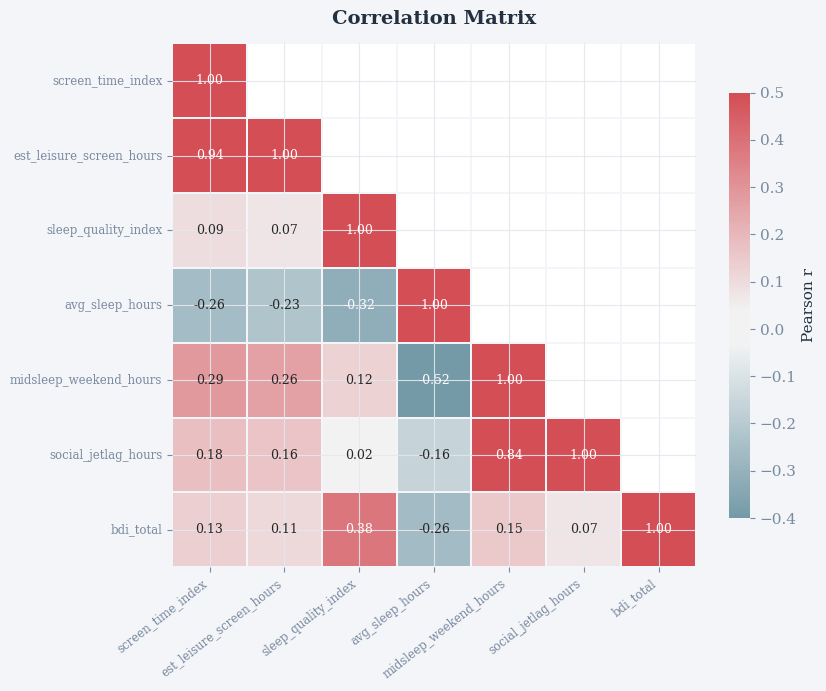

In [11]:

num_cols = ['screen_time_index','est_leisure_screen_hours','sleep_quality_index','avg_sleep_hours',
            'midsleep_weekend_hours','social_jetlag_hours','bdi_total']
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(8.5, 7))
cmap = sns.diverging_palette(220, 10, s=60, l=52, sep=20, as_cmap=True)
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap=cmap, center=0, vmin=-0.4, vmax=0.5,
            square=True, linewidths=1.2, linecolor=BG, cbar_kws={'shrink':0.8,'label':'Pearson r'},
            annot_kws={'fontsize':9}, ax=ax)
ax.set_title('Correlation Matrix', color=INK, pad=14)
plt.xticks(rotation=38, ha='right', fontsize=8.5)
plt.yticks(rotation=0, fontsize=8.5)
plt.tight_layout()
plt.show()


<h2 id="dashboard" style="font-family:Georgia,serif; color:#22303F; border-bottom:2px solid #4A5C73; padding-bottom:8px;">📈 12. Cohort Dashboard</h2>

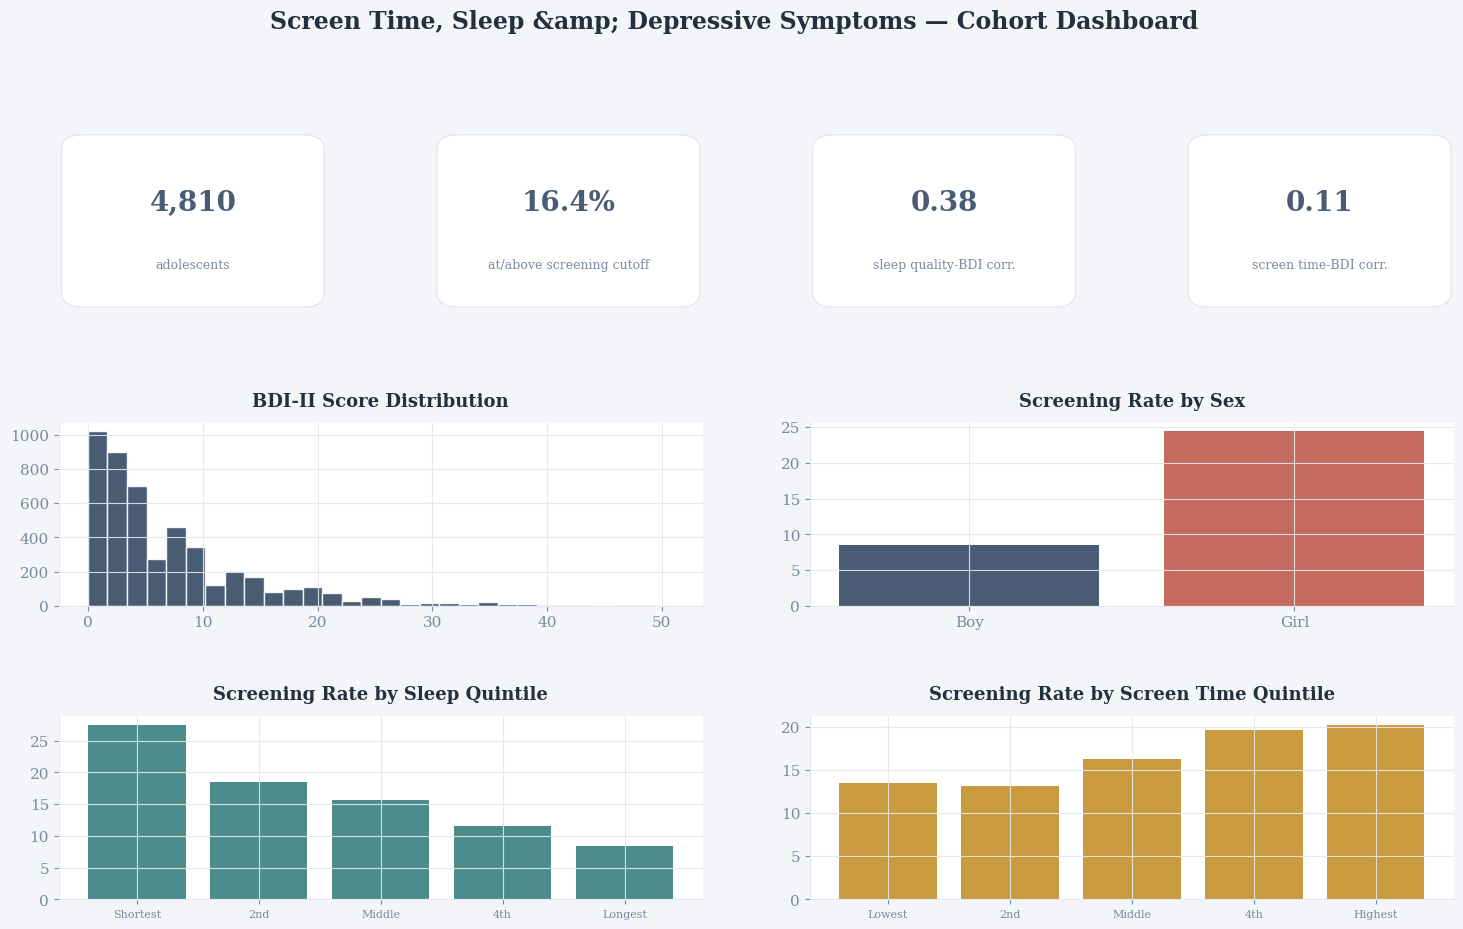

In [12]:

fig = plt.figure(figsize=(18, 10))
gs = fig.add_gridspec(3, 4, hspace=0.6, wspace=0.4)
fig.suptitle('Screen Time, Sleep &amp; Depressive Symptoms — Cohort Dashboard', fontsize=17, color=INK, fontweight='bold', y=1.0)

stat_cells = [
    (f"{len(df):,}", "adolescents"),
    (f"{df['depressed'].mean()*100:.1f}%", "at/above screening cutoff"),
    (f"{r:.2f}", "sleep quality-BDI corr."),
    (f"{r2:.2f}", "screen time-BDI corr."),
]
for i, (val, lab) in enumerate(stat_cells):
    ax = fig.add_subplot(gs[0, i]); ax.axis('off')
    ax.add_patch(FancyBboxPatch((0.03,0.05), 0.94, 0.9, boxstyle="round,pad=0.02,rounding_size=0.08",
                                 linewidth=1, edgecolor=GRID, facecolor=PANEL, transform=ax.transAxes))
    ax.text(0.5, 0.60, val, ha='center', va='center', fontsize=20, color=SLATE, fontweight='bold', transform=ax.transAxes)
    ax.text(0.5, 0.26, lab, ha='center', va='center', fontsize=9, color=INK_SOFT, transform=ax.transAxes)

ax = fig.add_subplot(gs[1, :2])
ax.hist(df['bdi_total'], bins=30, color=SLATE, edgecolor=BG)
style_ax(ax, 'BDI-II Score Distribution', '', '')

ax = fig.add_subplot(gs[1, 2:])
bars = ax.bar(sex_dep.index, sex_dep.values, color=[SEX_COLORS[s] for s in sex_dep.index])
style_ax(ax, 'Screening Rate by Sex', '', '')

ax = fig.add_subplot(gs[2, :2])
bars = ax.bar(sleep_dep.index.astype(str), sleep_dep.values, color=TEAL)
style_ax(ax, 'Screening Rate by Sleep Quintile', '', '')
plt.setp(ax.get_xticklabels(), fontsize=8)

ax = fig.add_subplot(gs[2, 2:])
bars = ax.bar(screen_dep.index.astype(str), screen_dep.values, color=AMBER)
style_ax(ax, 'Screening Rate by Screen Time Quintile', '', '')
plt.setp(ax.get_xticklabels(), fontsize=8)

plt.show()


<h2 id="model" style="font-family:Georgia,serif; color:#22303F; border-bottom:2px solid #4A5C73; padding-bottom:8px;">🤖 13. Predicting the Screening Classification</h2>
<p style="color:#7A8AA0; font-family:Georgia,serif;">We predict <code>depressed</code> from sleep, screen-time, and demographic fields only — deliberately excluding <code>bdi_total</code> and the individual items, since the classification is computed directly from those and including them would make this circular rather than a genuine test of the lifestyle factors.</p>

In [13]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, roc_curve, classification_report, confusion_matrix

model_df = df.copy()
model_df['sex'] = LabelEncoder().fit_transform(model_df['sex'])

features = ['sex','screen_time_index','est_leisure_screen_hours','sleep_quality_index','avg_sleep_hours',
            'midsleep_weekend_hours','social_jetlag_hours']
X = model_df[features]
y = model_df['depressed']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

log_reg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
log_reg.fit(X_train_s, y_train)
rf = RandomForestClassifier(n_estimators=300, max_depth=6, class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

models = {'Logistic Regression': (log_reg, X_test_s), 'Random Forest': (rf, X_test)}
results = {}
for name, (m, Xte) in models.items():
    proba = m.predict_proba(Xte)[:,1]
    auc = roc_auc_score(y_test, proba)
    results[name] = {'model': m, 'proba': proba, 'auc': auc}
    print(f"{name}: ROC-AUC = {auc:.3f}")


Logistic Regression: ROC-AUC = 0.742
Random Forest: ROC-AUC = 0.732


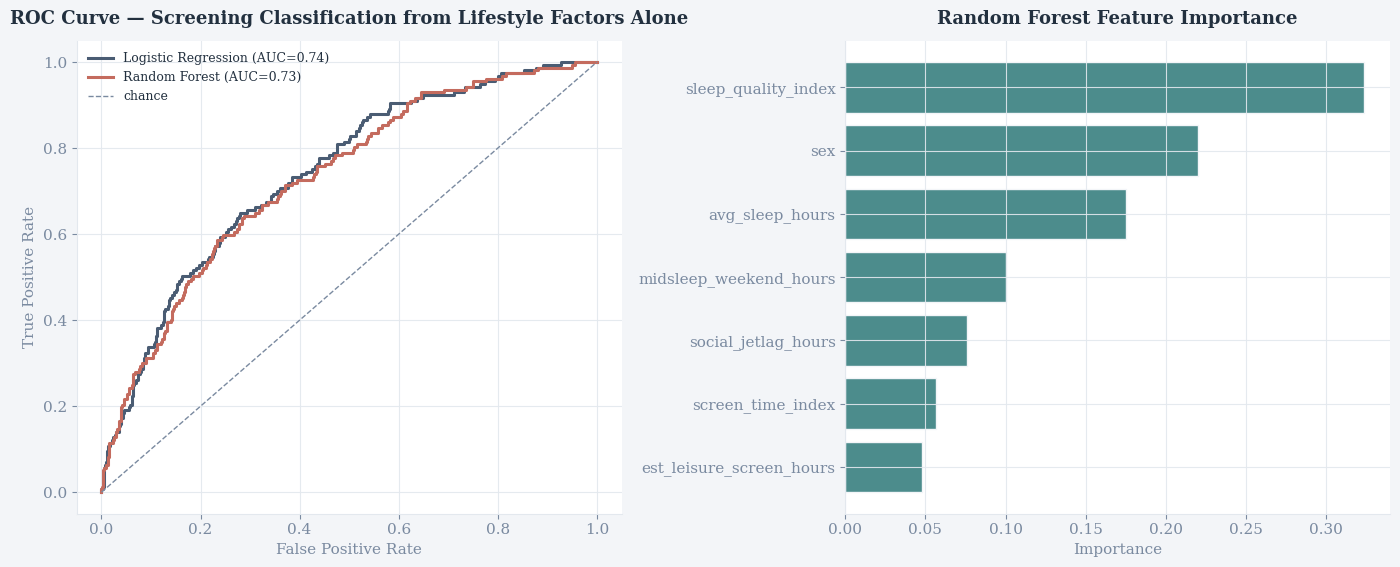

In [14]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5.8))

ax = axes[0]
for (name, res), c in zip(results.items(), [SLATE, CORAL]):
    fpr, tpr, _ = roc_curve(y_test, res['proba'])
    ax.plot(fpr, tpr, label=f"{name} (AUC={res['auc']:.2f})", color=c, linewidth=2.2)
ax.plot([0,1],[0,1], linestyle='--', color=INK_SOFT, linewidth=1, label='chance')
style_ax(ax, 'ROC Curve — Screening Classification from Lifestyle Factors Alone', 'False Positive Rate', 'True Positive Rate')
ax.legend(frameon=False, fontsize=9)

ax = axes[1]
importances = pd.Series(rf.feature_importances_, index=features).sort_values()
ax.barh(importances.index, importances.values, color=TEAL, edgecolor=BG)
style_ax(ax, 'Random Forest Feature Importance', 'Importance', '')

plt.tight_layout()
plt.show()



<div style="background:#EAF0F6; border-left:3px solid #4A5C73; padding:14px 20px; font-family:Georgia,serif; color:#2E3D4E; font-size:14px; border-radius:6px;">
Using only sleep and screen-time measures (no BDI content at all), the model reaches a moderate AUC — meaningfully
better than chance, but far from a reliable individual-level predictor. Sleep quality index carries the most
weight, consistent with every earlier section. This modest performance is exactly what we'd want to see: it says
sleep and screen habits are <i>associated</i> with depressive symptom screening results at a population level,
while confirming they're nowhere near sufficient to flag any individual student — which is appropriately outside
what a handful of lifestyle self-reports could ever responsibly claim to do.
</div>



<div style="background:#F3F5F8; padding:36px 40px; border-radius:8px; border-left:4px solid #4A5C73; font-family:Georgia,serif; color:#22303F;">

<h2 id="conclusion" style="margin-top:0; font-weight:700; color:#22303F; border-bottom:1px solid #D3DAE3; padding-bottom:10px;">📝 14. Closing Notes</h2>

<h4 style="color:#4A5C73; font-weight:700; margin-bottom:6px;">What the data shows</h4>
<ul style="line-height:1.9; font-size:14.5px; color:#333;">
<li>16.4% of this cohort scores at or above the standard BDI-II screening cutoff for at least mild depressive symptoms — a screening result, not a clinical diagnosis.</li>
<li>Girls show a notably higher screening rate (24.4%) than boys (8.6%), consistent with a large body of published adolescent mental health research.</li>
<li>Sleep quality is the strongest lifestyle correlate of BDI-II score in this dataset (r≈0.38) — clearly stronger than screen time (r≈0.13), suggesting sleep may matter more directly, or that screen time's effect partly runs through its impact on sleep.</li>
<li>A classifier built purely from sleep and screen-time measures reaches a moderate AUC — real population-level signal, but appropriately far from anything that could responsibly flag an individual.</li>
</ul>

<h4 style="color:#4A5C73; font-weight:700; margin-bottom:6px;">Handled carefully</h4>
<p style="font-size:14.5px; color:#333; line-height:1.8;">
Item-level BDI-II content was kept at an aggregate, anonymized level throughout (numbered generically rather than
described item-by-item), since the instrument's specific content is both copyrighted and not the point of a
cohort-level analysis like this one. The <code>bdi_total</code> and item columns were excluded from the prediction
model to avoid circularity, since <code>depressed</code> is computed directly from them.
</p>

<div style="margin-top:18px; padding:14px 18px; background:#EAF0F6; border-radius:8px;">
<p style="margin:0; font-size:13px; color:#2E3D4E; line-height:1.6;">
This is a sensitive topic. If anything here feels personally relevant, reaching out to a counselor, doctor, or
trusted adult is a good next step — support is available and reaching out matters.
</p>
</div>

<p style="text-align:right; margin-top:20px; margin-bottom:0; font-family:'Courier New',monospace; font-size:12px; color:#7A8AA0; letter-spacing:1px;">
— Muhammad Aamir
</p>

</div>
